In [2]:
import numpy as np

### rand and randn
 * rand - Uniform distribution of numbers between 0 and 1
 * randn - Normal distribution of numbers with median 0 and variance 1

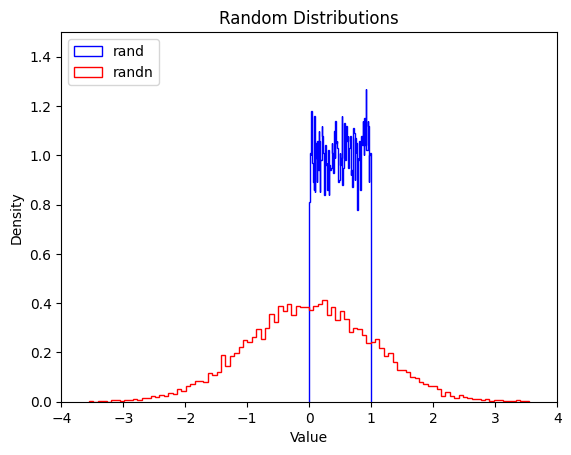

In [5]:
import matplotlib.pyplot as plt

plt.hist(np.random.rand(10000), density=True, bins=100, histtype="step", color="blue", label="rand")
plt.hist(np.random.randn(10000), density=True, bins=100, histtype="step", color="red", label="randn")
plt.axis([-4, 4, 0, 1.5])
plt.legend(loc="upper left")
plt.title("Random Distributions")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

### np.fromfunction

It's been told that the definition function will be called only once. But It's impossible. Exercise to check.

In [6]:
def f(x, y):
    print("I'm called")
    return x + y * 10

np.fromfunction(f, (5, 5), dtype=int)

I'm called


array([[ 0, 10, 20, 30, 40],
       [ 1, 11, 21, 31, 41],
       [ 2, 12, 22, 32, 42],
       [ 3, 13, 23, 33, 43],
       [ 4, 14, 24, 34, 44]])

### Arithmetic Operations

 * All operations are applied element wise
 * The multiplication is element wise multiplication. Not matrix dot product.
 * When the arrays don't match size, NumPy will apply broadcasting rules

Let's check broadcasting rules below. Still confusing. Reserving for later when required.

In [8]:
a = np.array([[1, 2, 3]])
b = np.array([[10, 20]])

a + b
a * b

ValueError: operands could not be broadcast together with shapes (1,3) (1,2) 

### Conditional Operators

Similar to arithmetic, conditional operations work element-wise.

Most useful is boolean indexing. Like creating a sub-array with a conditional operation.

In [10]:
a = np.array([20, 21, 22, 23, 24, 25, 26, 27, 28, 29])
a < 25

a[a < 25]

array([20, 21, 22, 23, 24])

### Axis wise operation

**Developing the intuition is important**

Considering in dimensions with axis is not very helpful. Also, it is not scaling beyond 3 dimensions. So, just reduce one dimension and sum all values in that dimension. The order of values in the shape function is the order of axis-0 to axis-n

In [ ]:
c = np.arange(24).reshape(2, 3, 4)
c

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [25]:
b = [
        [
            c[0][0][0] + c[1][0][0], c[0][0][1] + c[1][0][1], c[0][0][2] + c[1][0][2], c[0][0][3] + c[1][0][3]
        ],
        [
            c[0][1][0] + c[1][1][0], c[0][1][1] + c[1][1][1], c[0][1][2] + c[1][1][2], c[0][1][3] + c[1][1][3]
        ],
        [
            c[0][2][0] + c[1][2][0], c[0][2][1] + c[1][2][1], c[0][2][2] + c[1][2][2], c[0][2][3] + c[1][2][3]
        ]
    ]
b

[[np.int64(12), np.int64(14), np.int64(16), np.int64(18)],
 [np.int64(20), np.int64(22), np.int64(24), np.int64(26)],
 [np.int64(28), np.int64(30), np.int64(32), np.int64(34)]]

In [19]:
c.sum(axis=0)

array([[12, 14, 16, 18],
       [20, 22, 24, 26],
       [28, 30, 32, 34]])

In [18]:
c.sum(axis=1)

array([[12, 15, 18, 21],
       [48, 51, 54, 57]])

In [26]:
b = [
        [
            c[0][0][0] + c[0][0][1] + c[0][0][2] + c[0][0][3], c[0][1][0] + c[0][1][1] + c[0][1][2] + c[0][1][3], c[0][2][0] + c[0][2][1] + c[0][2][2] + c[0][2][3]
        ],
        [
            c[1][0][0] + c[1][0][1] + c[1][0][2] + c[1][0][3], c[1][1][0] + c[1][1][1] + c[1][1][2] + c[1][1][3], c[1][2][0] + c[1][2][1] + c[1][2][2] + c[1][2][3]
        ]
]
b

[[np.int64(6), np.int64(22), np.int64(38)],
 [np.int64(54), np.int64(70), np.int64(86)]]

In [15]:
c.sum(axis=2)

array([[ 6, 22, 38],
       [54, 70, 86]])

# -x- 08/Oct/2025 -x-

### Accessing Elements

In [ ]:
b = np.arrange(48).reshape(4, 12)
print(b)

# row 1, col 2
print(b[1, 2])


# row 1, all columns
print(b[1, :])

# all rows, col 1
print(b[:, 1])

# row 1 as column vector
print(b[1:2, :])

### Fancy Indexing

Specify only interested indexes

In [ ]:
# rows 0 and 2, columns 2 to 5
print(b[(0,2), 2:5])

# All rows, last column (-1), col 2 and again last column
print(b[:, (-1, 2, -1)])

# When multiple index arrays are provided, they're combined as points
print(b[(-1, 2, -1, 2), (5, 9, 1, 9)])  # returns a 1D array with b[-1, 5], b[2, 9], b[-1, 1] and b[2, 9] (again)

# If you omit coordinates for any axis, all elements in that axis are selected
print(b[(-1, 2, -1, 2)])

b = b.reshape(4, 3, 4)
print(b)

# Ellipsis (...)
print(b[1, ...]) # same as b[1, :, :]


### Transpose

In [5]:
t = np.arange(24).reshape(2, 3, 4)
print(t)
print()

transposed = t.transpose(1, 0, 2) # Arguments are the new order of the axes
print(transposed)
print()

print(t.transpose()) # Default is to reverse the order of the axes


[[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]]

[[[ 0  1  2  3]
  [12 13 14 15]]

 [[ 4  5  6  7]
  [16 17 18 19]]

 [[ 8  9 10 11]
  [20 21 22 23]]]

[[[ 0 12]
  [ 4 16]
  [ 8 20]]

 [[ 1 13]
  [ 5 17]
  [ 9 21]]

 [[ 2 14]
  [ 6 18]
  [10 22]]

 [[ 3 15]
  [ 7 19]
  [11 23]]]
